# Student Performance Indicator

## Life Cycle of Machine Learning Project
- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory Data Analysis
- Data Pre-Processing
- Model Training
- Choose Best Model

### 1. Understanding the Problem Statement

- This Project understands how the student's Performance (test scores) is affected by other variables such as Gender, ethnicity, parental level of education, Lunch, test preparation course

### 2. Data Collection

- Data Source :- https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- This Dataset contains 1000 rows and 8 columns

#### 2.1 Import Data and Required Packages

##### Import Packages and Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

##### Import the CSV Data as Pandas Dataframe

In [4]:
df = pd.read_csv('stud.csv')

##### Show Top 5 Records

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


##### Shape of the Dataset

In [6]:
df.shape

(1000, 8)

### 2.2 Dataset Information

- Gender -> Sex of Students -> Male, Female
- Race_Ethnicity -> Ethnicity of Students -> Group A, Group B, Group C, Group D, Group E
- Parental Level of Education -> Parent's Final Education -> "bachelor's degree", "some college", "master's degree", "associate's degree", "high school", "some high school"
- Lunch -> Having lunch before test -> standard, free/reduced
- Test Preparation Course -> complete or not complete before the test -> none, completed
- Math Score
- Reading Score
- Writing Score

#### 3.Data Checks to perform
- Check Missing Values
- Check Duplicate Values
- Check Datatypes
- Checking the number of unique values in each column
- Check Statistics of the Dataset
- Check Various Categories present in the different categorical columns

##### 3.1 Check Missing Values

In [7]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

##### There are no missing values in the dataset

##### 3.2 Check Duplicate Values

In [8]:
df.duplicated().sum()

np.int64(0)

##### There are no Duplicate values available in dataset

#### 3.3 Check Datatypes

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


#### 3.4 Checking the number of unique values in each column

In [10]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

#### 3.5 Check Statistics of the Dataset

In [11]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


##### Insights
- From the above description of numerical values, mean values are very close to each other ranging from 66.08 - 69.16
- All the standard deviations are also close to each other, ranging from 14.6 - 15.19
- For minimum scores :- In maths we have 0 min score, In reading we have 17 as min score, In writing we have 10 as min score

#### 3.6 Exploring Data

In [12]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
print("Categories in 'gender' variable : ", end = "")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable : ", end = "")
print(df['race_ethnicity'].unique())

print("Categories in 'parental_level_of_education' variable : ", end = "")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable : ", end = "")
print(df['lunch'].unique())

print("Categories in 'test_preparation_course' variable : ", end = "")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable : ['female' 'male']
Categories in 'race_ethnicity' variable : ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education' variable : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable : ['standard' 'free/reduced']
Categories in 'test_preparation_course' variable : ['none' 'completed']


In [14]:
# Define Numeric Columns and Categorical Columns

numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print("We have {} numeric features : {}".format(len(numeric_features), numeric_features))
print("We have {} categorical features : {}".format(len(categorical_features), categorical_features))

We have 3 numeric features : ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [15]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### 3.7 Adding Columns for "Total Score" and "Average"

In [16]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [17]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f"Number of Students who scored Full marks in Reading : {reading_full}")
print(f"Number of Students who scored Full marks in Writing : {writing_full}")
print(f"Number of Students who scored Full marks in Maths : {math_full}")

Number of Students who scored Full marks in Reading : 17
Number of Students who scored Full marks in Writing : 14
Number of Students who scored Full marks in Maths : 7


In [18]:
reading_less_than_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_than_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_than_20 = df[df['math_score'] <= 20]['average'].count()

print(f"Number of Students who scored Full marks in Reading : {reading_less_than_20}")
print(f"Number of Students who scored Full marks in Writing : {writing_less_than_20}")
print(f"Number of Students who scored Full marks in Maths : {math_less_than_20}")

Number of Students who scored Full marks in Reading : 1
Number of Students who scored Full marks in Writing : 3
Number of Students who scored Full marks in Maths : 4


##### Insights
- From the above values, the worst performance is in maths
- Best Performance in Reading

### 4. Exploring Data (Data Visualization)
#### 4.1 Visualize Average score distribution to make some conclusion
- Histogram
- Kernal Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

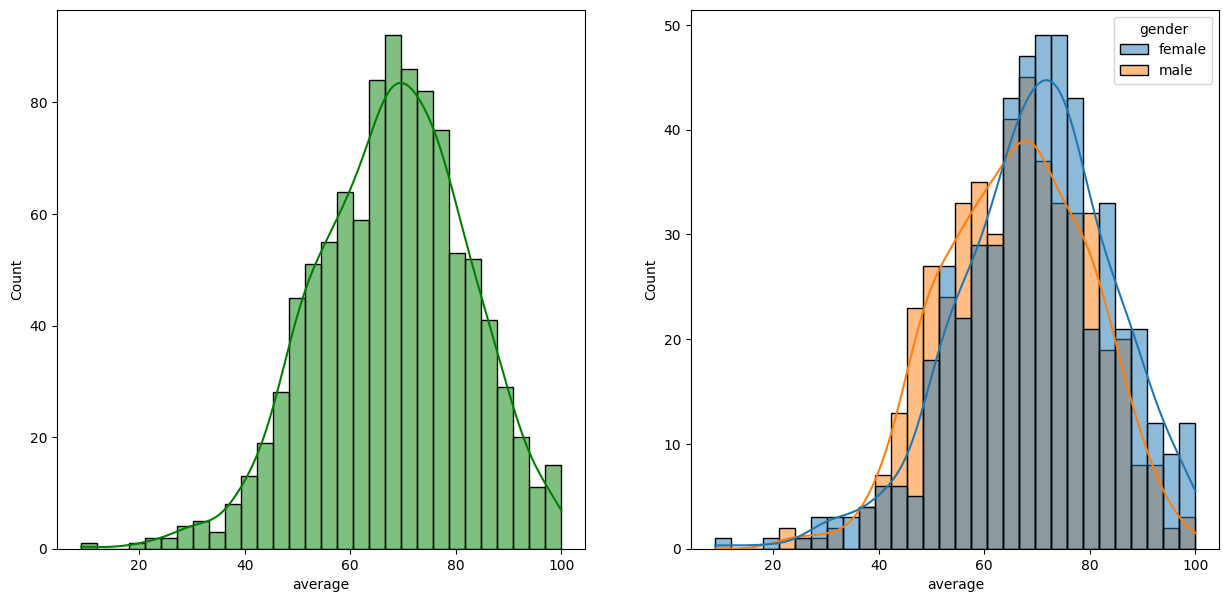

In [19]:
fig, axs = plt.subplots(1,2, figsize = (15,7))
plt.subplot(1,2,1)
sns.histplot(data = df, x = 'average', bins = 30, kde = True, color = 'g')
plt.subplot(1,2,2)
sns.histplot(data = df, x = 'average', bins = 30, kde = True, hue = 'gender')
plt.show()

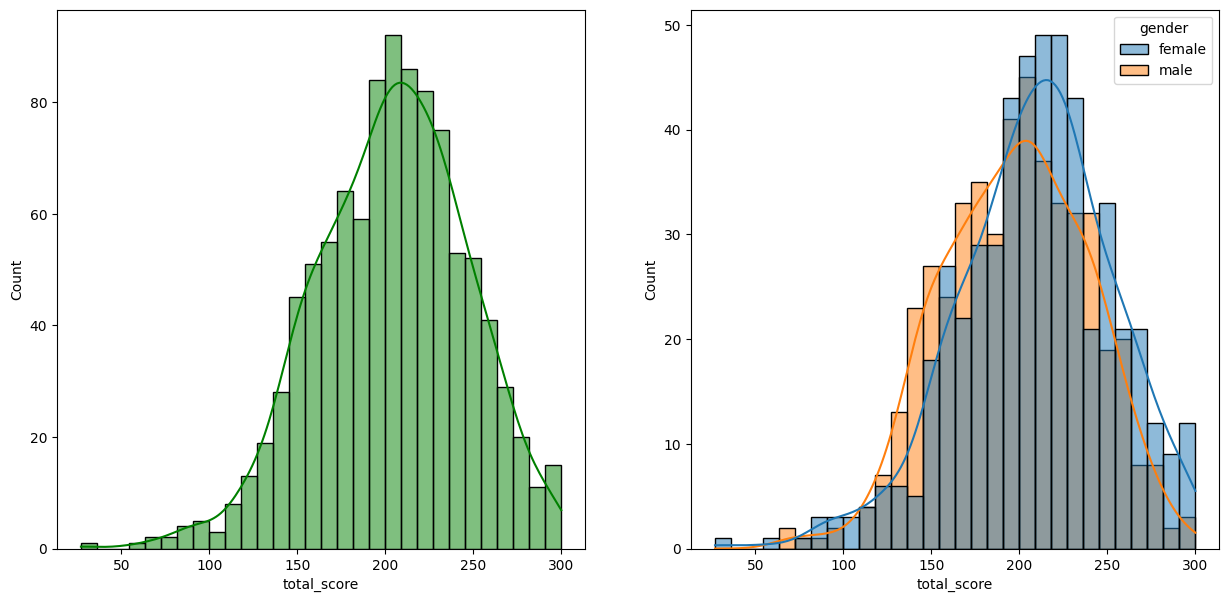

In [20]:
fig, axs = plt.subplots(1,2, figsize = (15,7))
plt.subplot(1,2,1)
sns.histplot(data = df, x = 'total_score', bins = 30, kde = True, color = 'g')
plt.subplot(1,2,2)
sns.histplot(data = df, x = 'total_score', bins = 30, kde = True, hue = 'gender')
plt.show()

##### Insights
- Female students tend to perform better than male students

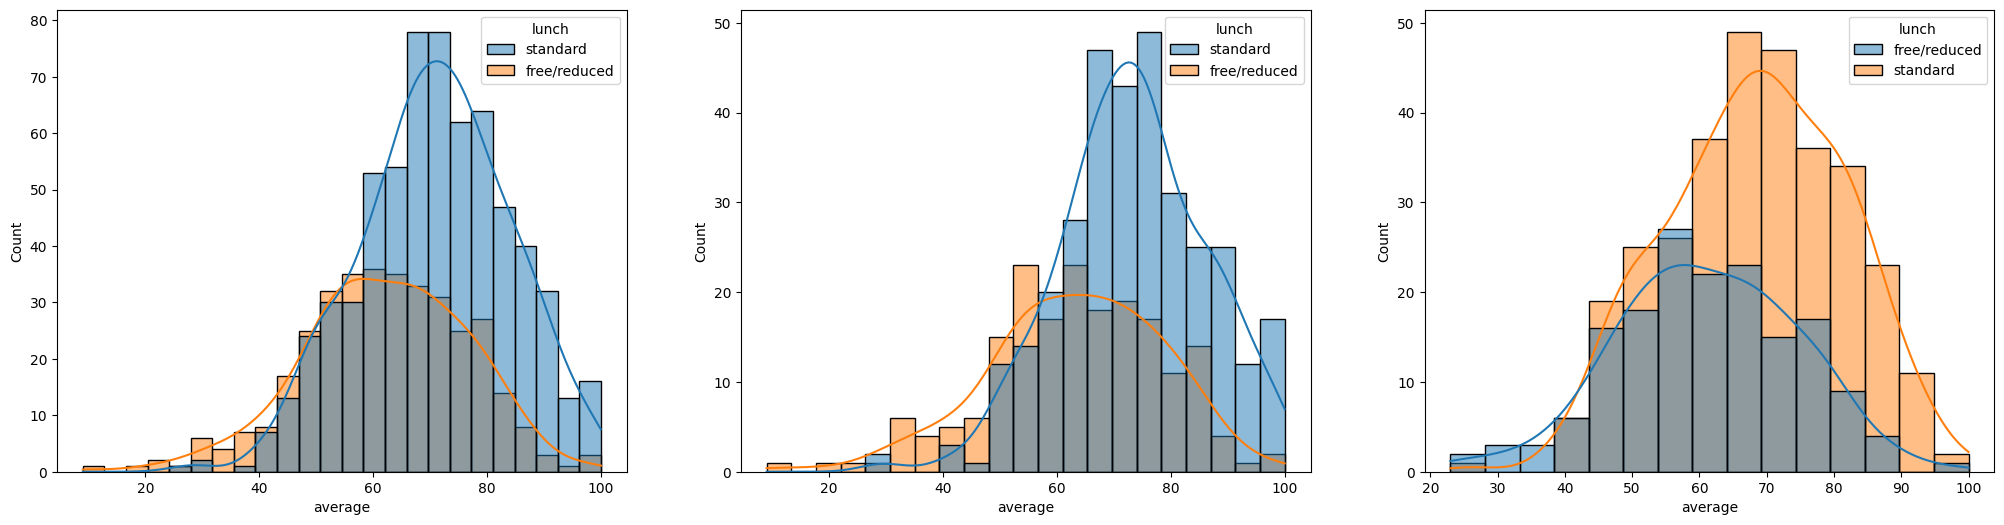

In [21]:
fig, axes = plt.subplots(1,3, figsize = (25, 6))
plt.subplot(1,3,1)
sns.histplot(data = df, x = 'average', kde = True, hue = 'lunch')
plt.subplot(1,3,2)
sns.histplot(data = df[df['gender'] == 'female'], x = 'average', kde = True, hue = 'lunch')
plt.subplot(1,3,3)
sns.histplot(data = df[df['gender'] == 'male'], x = 'average', kde = True, hue = 'lunch')
plt.show()

##### Insights
- Standard lunch helps perform well in exams
- Standard lunch helps perform well in exams be it a male or a female

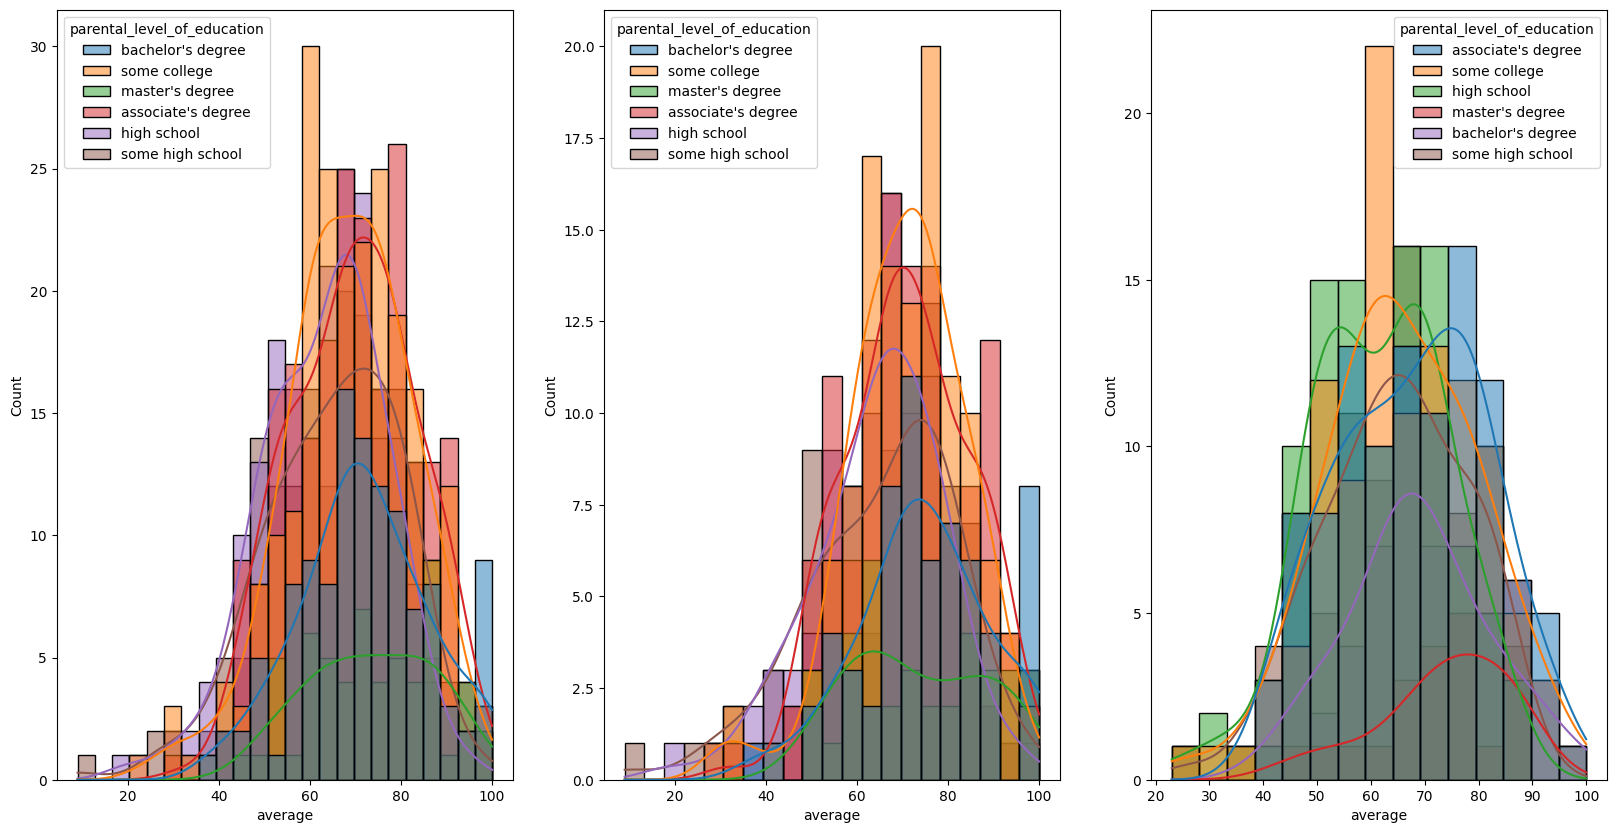

In [22]:
fig, axes = plt.subplots(1,3, figsize = (20, 10))
plt.subplot(1,3,1)
sns.histplot(data = df, x = 'average', kde = True, hue = 'parental_level_of_education')
plt.subplot(1,3,2)
sns.histplot(data = df[df['gender'] == 'female'], x = 'average', kde = True, hue = 'parental_level_of_education')
plt.subplot(1,3,3)
sns.histplot(data = df[df['gender'] == 'male'], x = 'average', kde = True, hue = 'parental_level_of_education')
plt.show()

##### Insights
- In general parent's education don't help student perform well in exam
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students

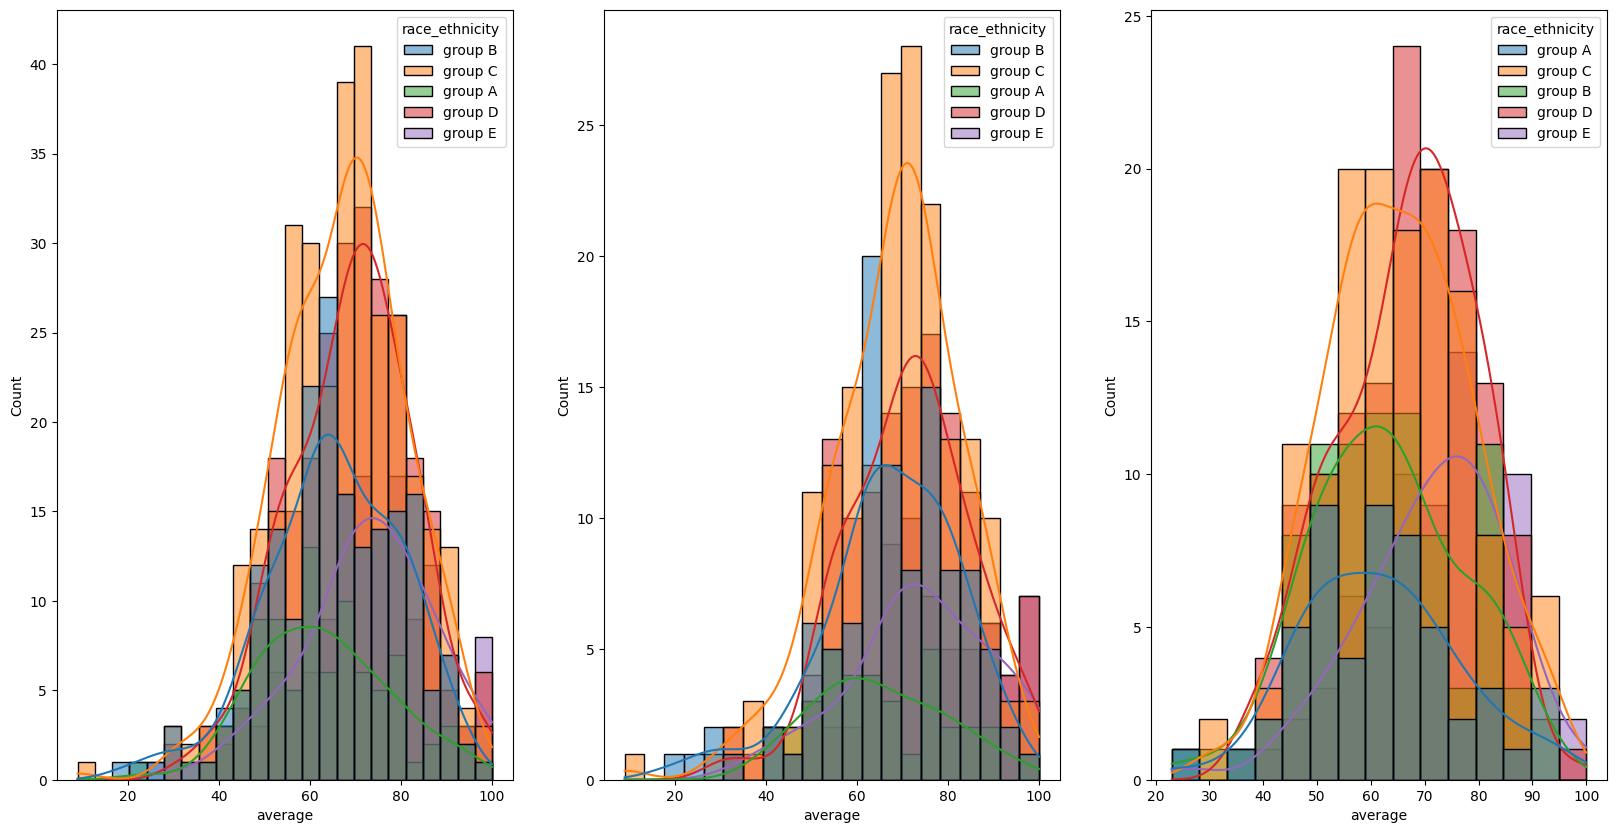

In [23]:
fig, axes = plt.subplots(1,3, figsize = (20, 10))
plt.subplot(1,3,1)
sns.histplot(data = df, x = 'average', kde = True, hue = 'race_ethnicity')
plt.subplot(1,3,2)
sns.histplot(data = df[df['gender'] == 'female'], x = 'average', kde = True, hue = 'race_ethnicity')
plt.subplot(1,3,3)
sns.histplot(data = df[df['gender'] == 'male'], x = 'average', kde = True, hue = 'race_ethnicity')
plt.show()

##### Insights
- Students of Group A and Group B tends to perform poorly in exam
- Students of Group A and Group B tends to perform poorly in exam irrespective of whether they are male or female

#### 4.2 Maximum Score of students in all three subjects

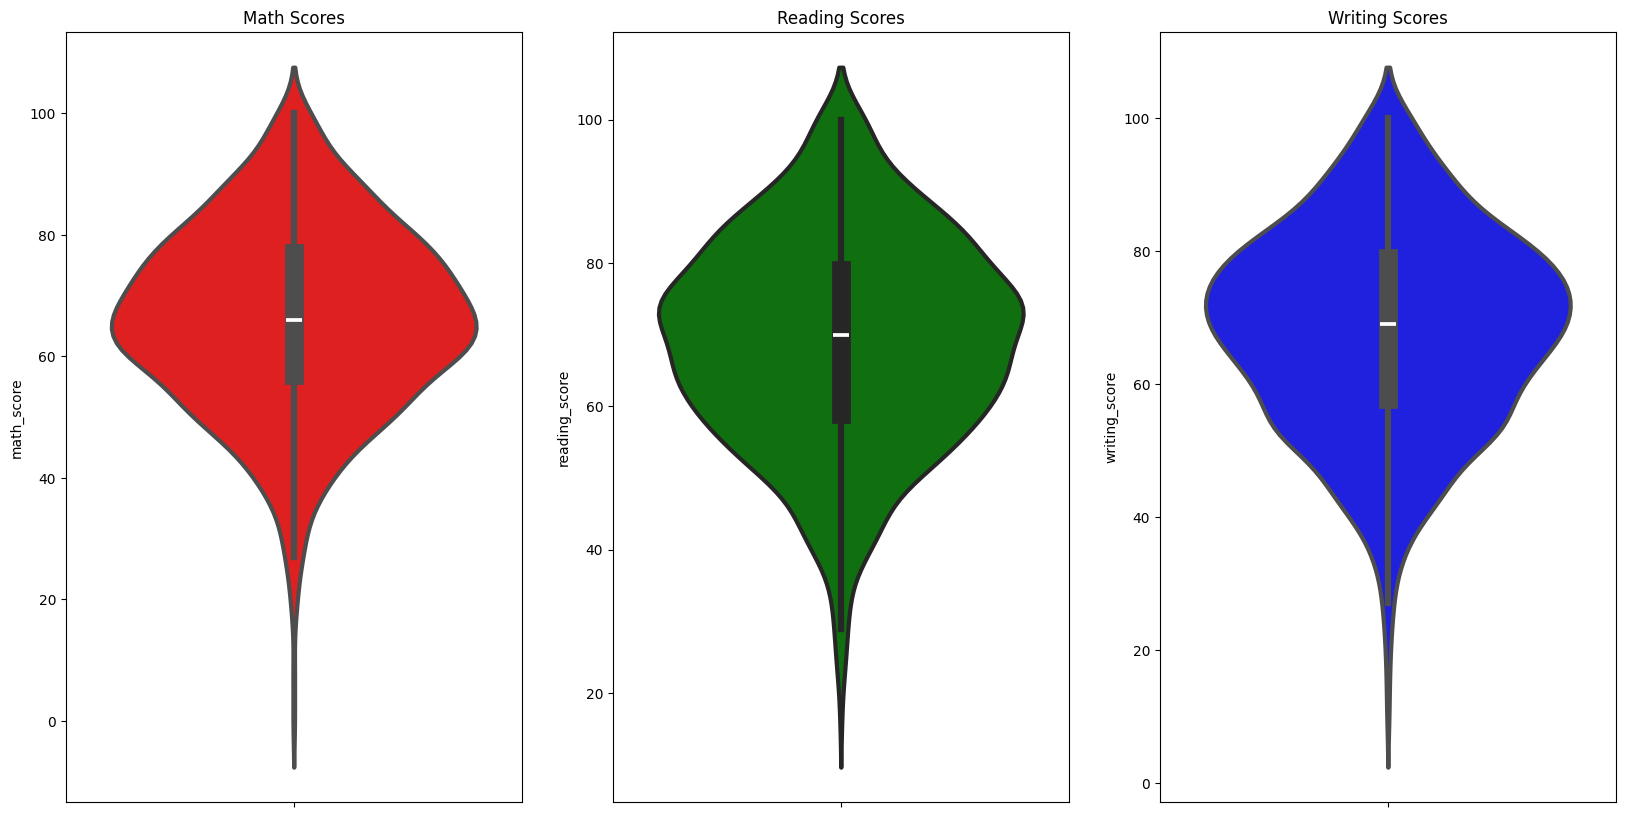

In [24]:
plt.figure(figsize = (20,10))
plt.subplot(1,3,1)
plt.title("Math Scores")
sns.violinplot(data = df, y = 'math_score', color = 'red', linewidth = 3)
plt.subplot(1,3,2)
plt.title("Reading Scores")
sns.violinplot(data = df, y = 'reading_score', color = 'green', linewidth = 3)
plt.subplot(1,3,3)
plt.title("Writing Scores")
sns.violinplot(data = df, y = 'writing_score', color = 'blue', linewidth = 3)
plt.show()

##### Insights
- From the above three plots it's clearly visible that most of the students score in between 60-80 in maths whereas in reading and writing most of them score from 50-80

#### 4.3 Multivariate Analysis using pieplot

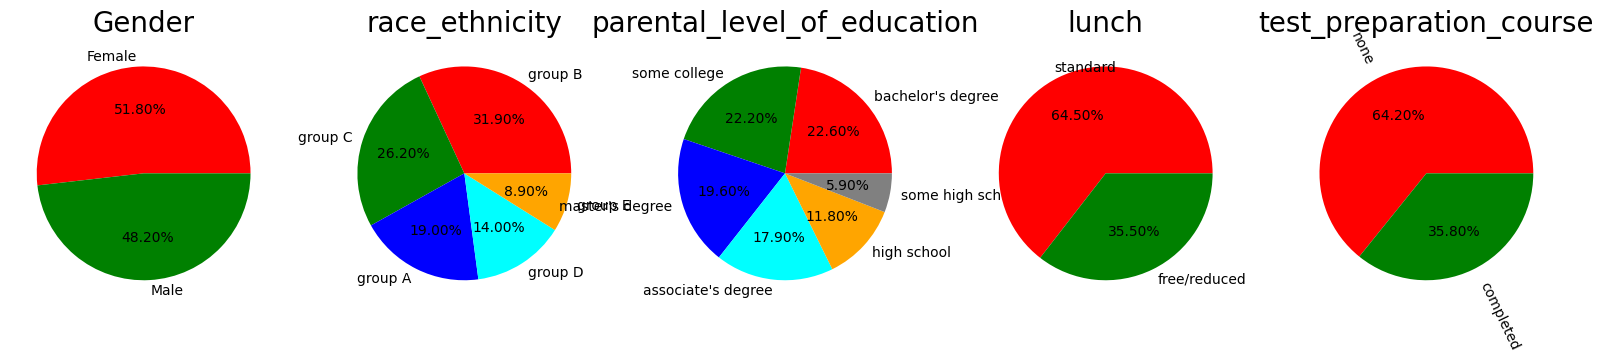

In [25]:
fig, axs = plt.subplots(1,5, figsize = (20, 10))

plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = '%.2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')

plt.subplot(1,5,2)
size = df['race_ethnicity'].value_counts()
labels = 'group B','group C','group A','group D','group E'
color = ['red', 'green', 'blue', 'cyan', 'orange']

plt.pie(size, colors = color, labels = labels, autopct = '%.2f%%')
plt.title('race_ethnicity', fontsize = 20)
plt.axis('off')

plt.subplot(1,5,3)
size = df['parental_level_of_education'].value_counts()
labels = ["bachelor's degree",'some college',"master's degree","associate's degree",'high school','some high school']
color = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']

plt.pie(size, colors = color, labels = labels, autopct = '%.2f%%')
plt.title('parental_level_of_education', fontsize = 20)
plt.axis('off')

plt.subplot(1,5,4)
size = df['lunch'].value_counts()
labels = ['standard','free/reduced']
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = '%.2f%%', center=(10,10))
plt.title('lunch', fontsize = 20)
plt.axis('off')

plt.subplot(1,5,5)
size = df['test_preparation_course'].value_counts()
labels = ['none','completed']
color = ['red', 'green']

plt.pie(size, colors = color, labels = labels, autopct = '%.2f%%', rotatelabels=True)
plt.title('test_preparation_course', fontsize = 20)
plt.axis('off')
plt.show()

##### Insights
- Number of Male and Female Students are almost equal
- Number of students are greatest in Group C
- Number of student's whose parental education is "Some college" is greater followed closely by "Associate's Degree."
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater

#### 4.4 Feature Wise Visualization

#### 4.4.1 Gender Column
- How is distribution of gender
- Is gender has any impact on student's performance

#### Univariate Analysis (How is distribution of gender ?)

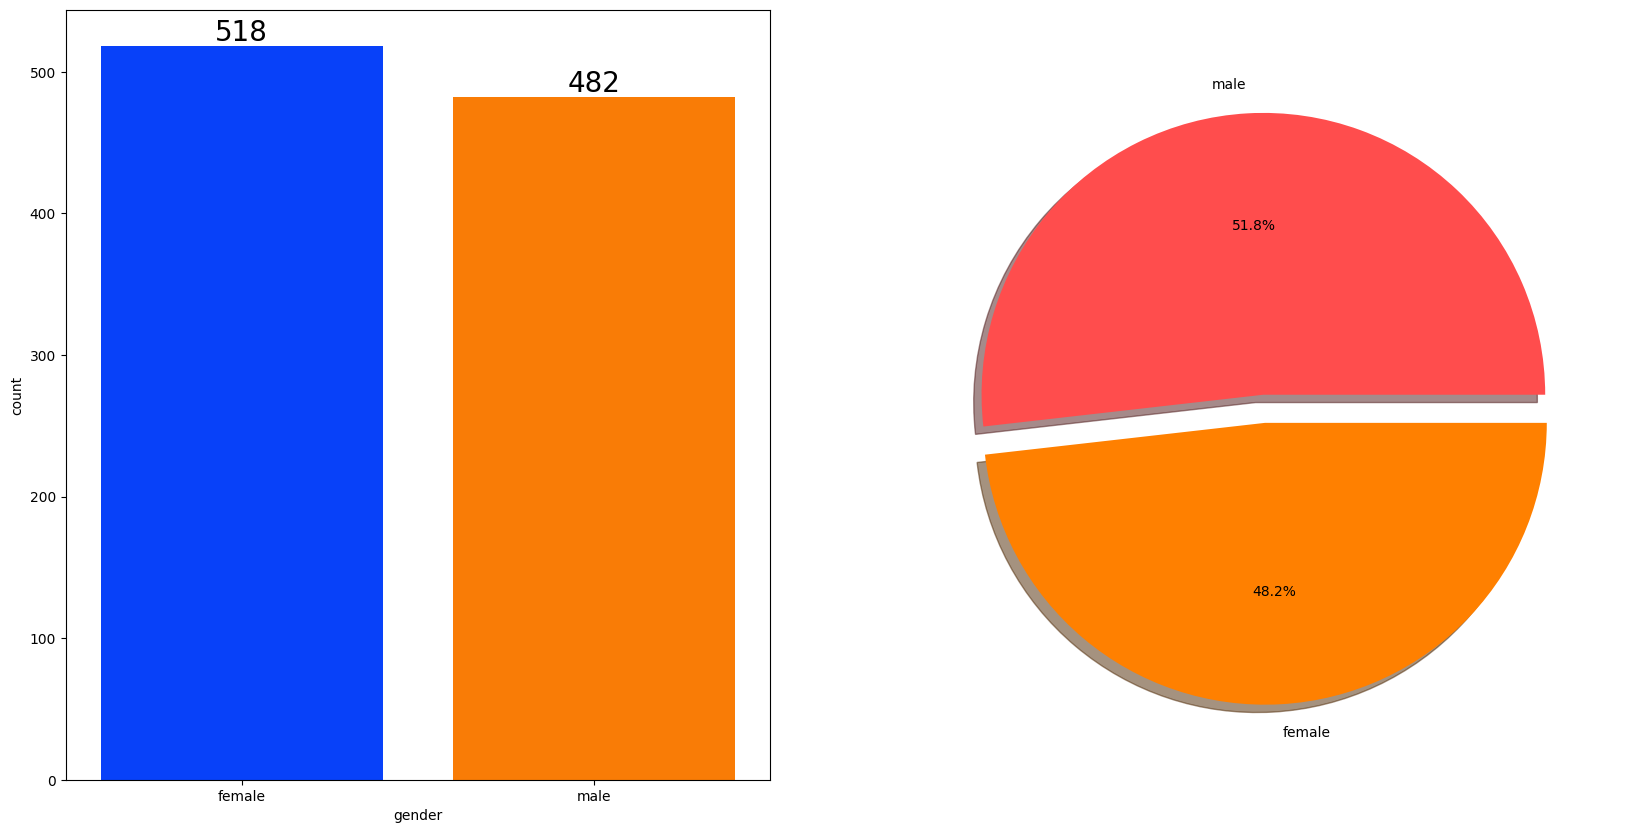

In [26]:
f, ax = plt.subplots(1,2, figsize = (20,10))
sns.countplot(x = df['gender'], data = df, palette = 'bright', ax = ax[0], saturation = 0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 20)

plt.pie(x = df['gender'].value_counts(), labels = ['male', 'female'], explode = [0,0.1], autopct = '%1.1f%%', shadow = True, colors = ['#ff4d4d', '#ff8000'] )
plt.show()

##### Insights
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)

#### Bivariate Analysis (Is gender has any impact on student's performance ?)

In [27]:
gender_group = df.groupby('gender').mean(numeric_only = True)
gender_group

,math_score,reading_score,writing_score,total_score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


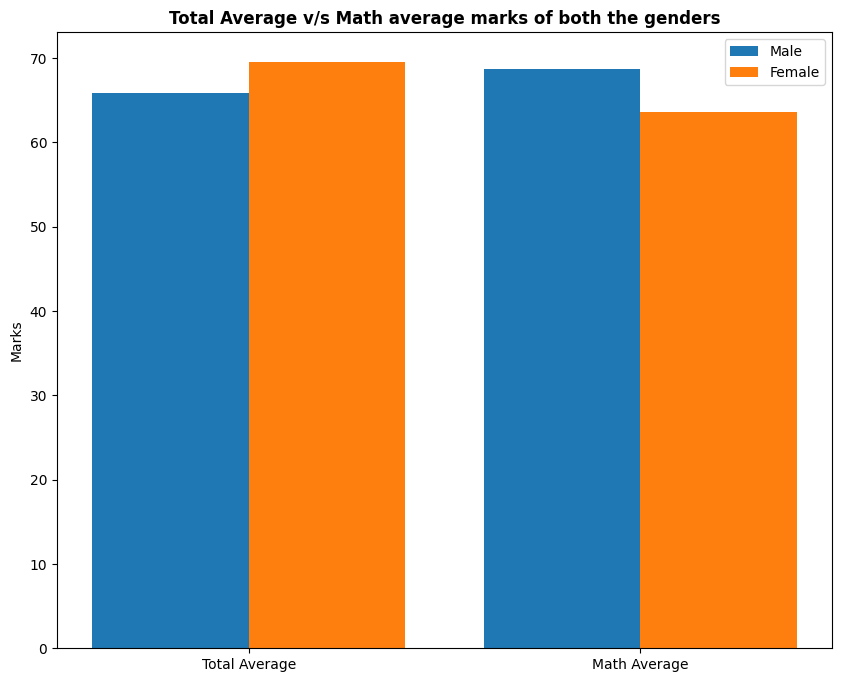

In [28]:
plt.figure(figsize = (10, 8))

X = ['Total Average', 'Math Average']

female_scores = [gender_group['average'][0], gender_group['math_score'][0]]
male_scores = [gender_group['average'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total Average v/s Math average marks of both the genders", fontweight = 'bold')
plt.legend()
plt.show()

##### Insights
- On an average females have a better overall score than men
- Wheras males have scored higher in maths

#### 4.4.2 Race_Ethnicity Column
- How is group wise distribution ?
- Is race_ethnicity has any impact on student's performance ?

#### Univariate Analysis (How is group wise distribution ?)

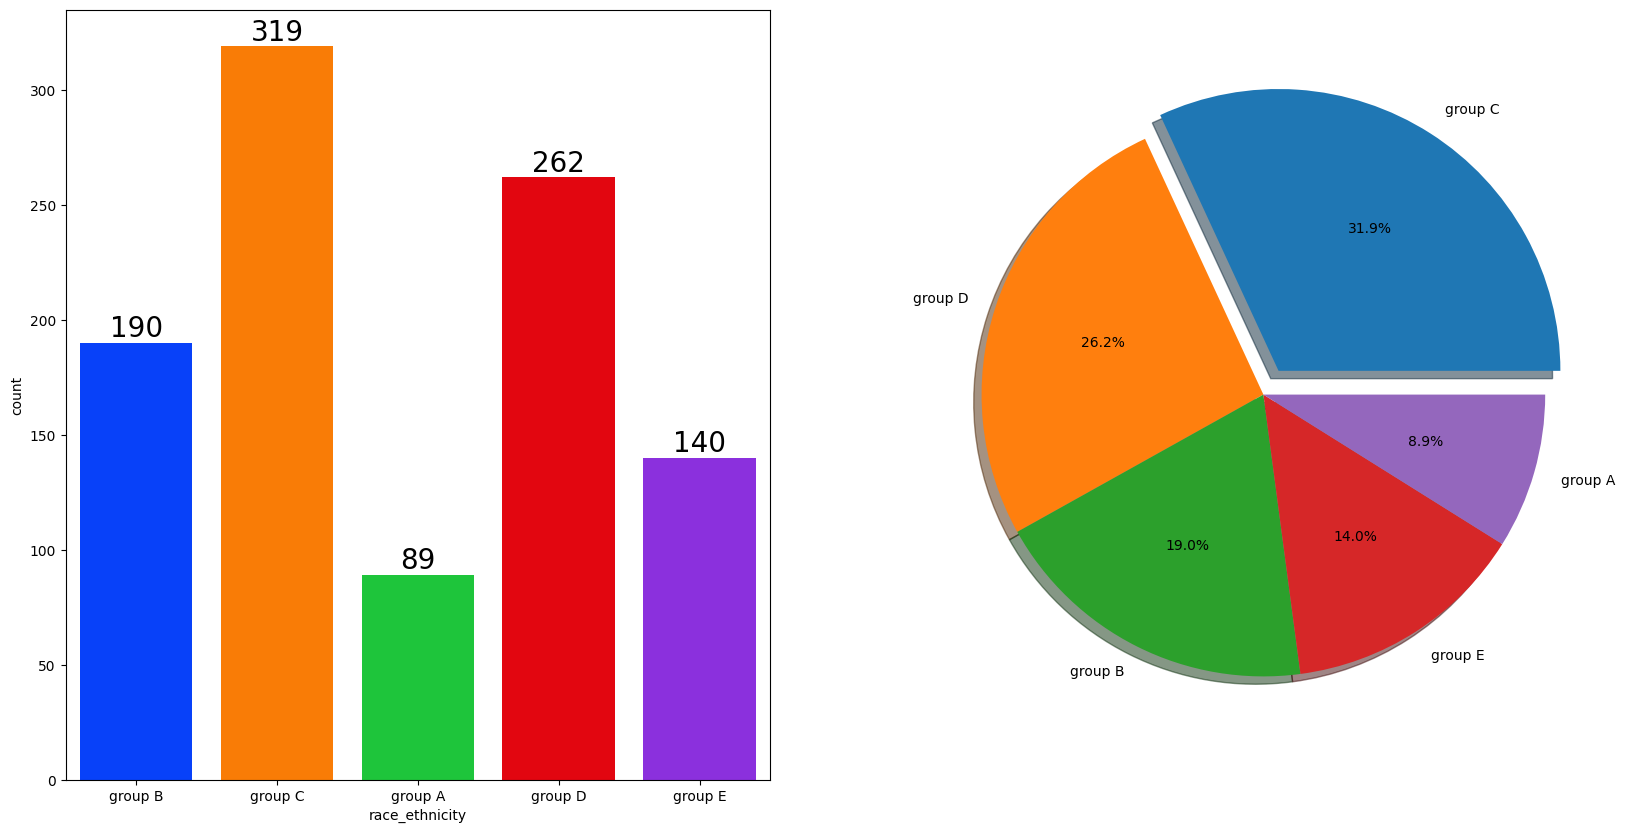

In [29]:
f, ax = plt.subplots(1,2, figsize = (20,10))
sns.countplot(data = df, x = df['race_ethnicity'], palette = 'bright', ax = ax[0], saturation = 0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 20)

plt.pie(x = df['race_ethnicity'].value_counts(), labels = df['race_ethnicity'].value_counts().index, explode = [0.1,0,0,0,0], autopct = '%1.1f%%', shadow = True)
plt.show()

##### Insights
- Most of the student belonging from Group C/ Group D
- Lowest number of students belong to Group A

#### Bivariate Analysis (Is race_ethnicity has any impact on student's performance ?)

In [30]:
group_data2 = df.groupby('race_ethnicity').mean(numeric_only = True)
group_means_math = group_data2.groupby('race_ethnicity')['math_score'].mean()
group_means_reading = group_data2.groupby('race_ethnicity')['reading_score'].mean()
group_means_writing = group_data2.groupby('race_ethnicity')['writing_score'].mean()

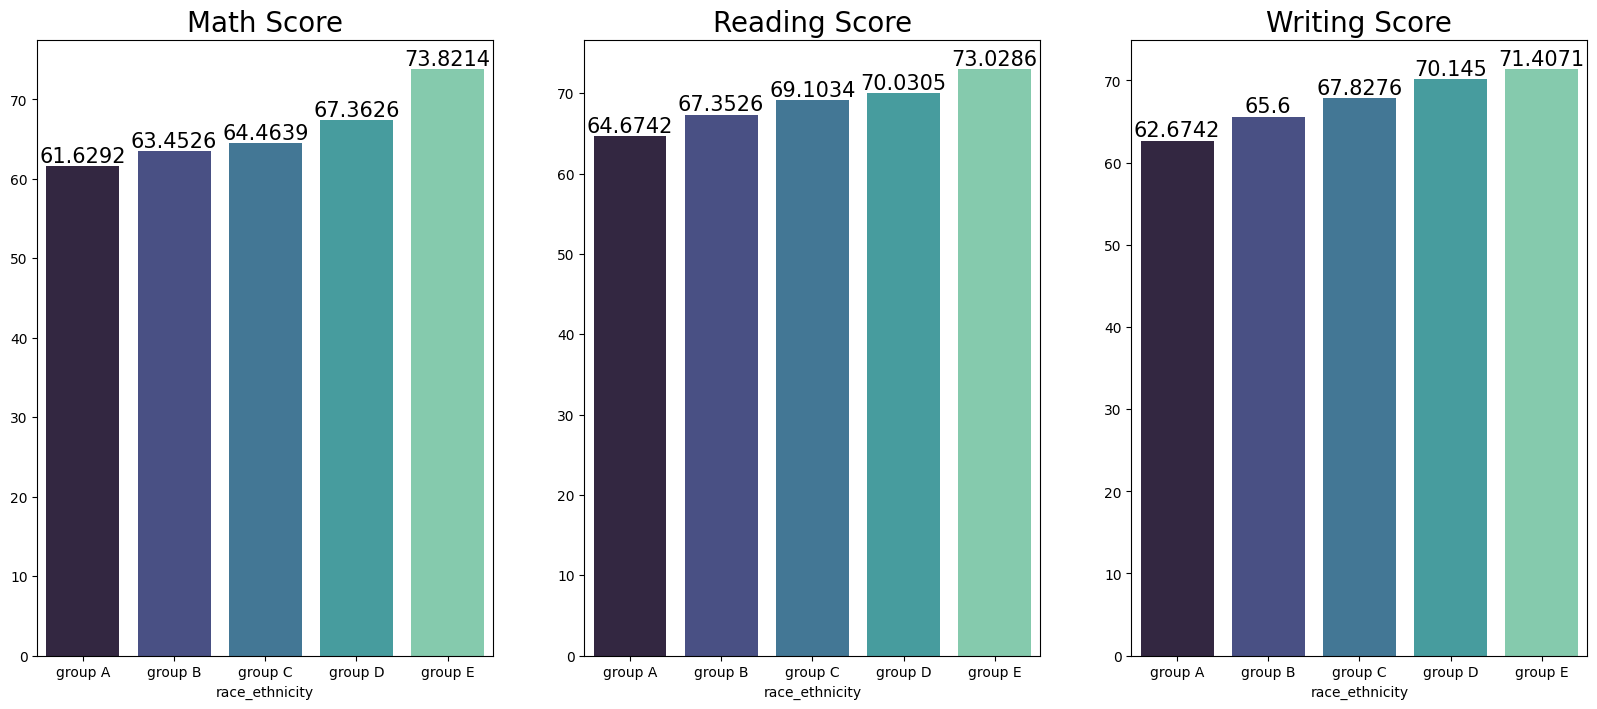

In [31]:
f, ax = plt.subplots(1,3, figsize = (20,8))
sns.barplot(x = group_means_math.index, y = group_means_math.values, palette = 'mako', ax = ax[0])
ax[0].set_title ('Math Score', color = 'black', size = 20)

for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', fontsize = 15)

sns.barplot(x = group_means_reading.index, y = group_means_reading.values, palette = 'mako', ax = ax[1])
ax[1].set_title ('Reading Score', color = 'black', size = 20)

for container in ax[1].containers:
    ax[1].bar_label(container, color = 'black', fontsize = 15)

sns.barplot(x = group_means_writing.index, y = group_means_writing.values, palette = 'mako', ax = ax[2])
ax[2].set_title ('Writing Score', color = 'black', size = 20)

for container in ax[2].containers:
    ax[2].bar_label(container, color = 'black', fontsize = 15)

plt.show()

##### Insights
- Group E students have scored the highest marks
- Group A students have scored the lowest marks
- Student's from a lower socioeconomic status have a lower average in all course subjects

#### 4.4.3 Parental level of education
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### Univariate Analysis (What is educational background of student's parent ?)

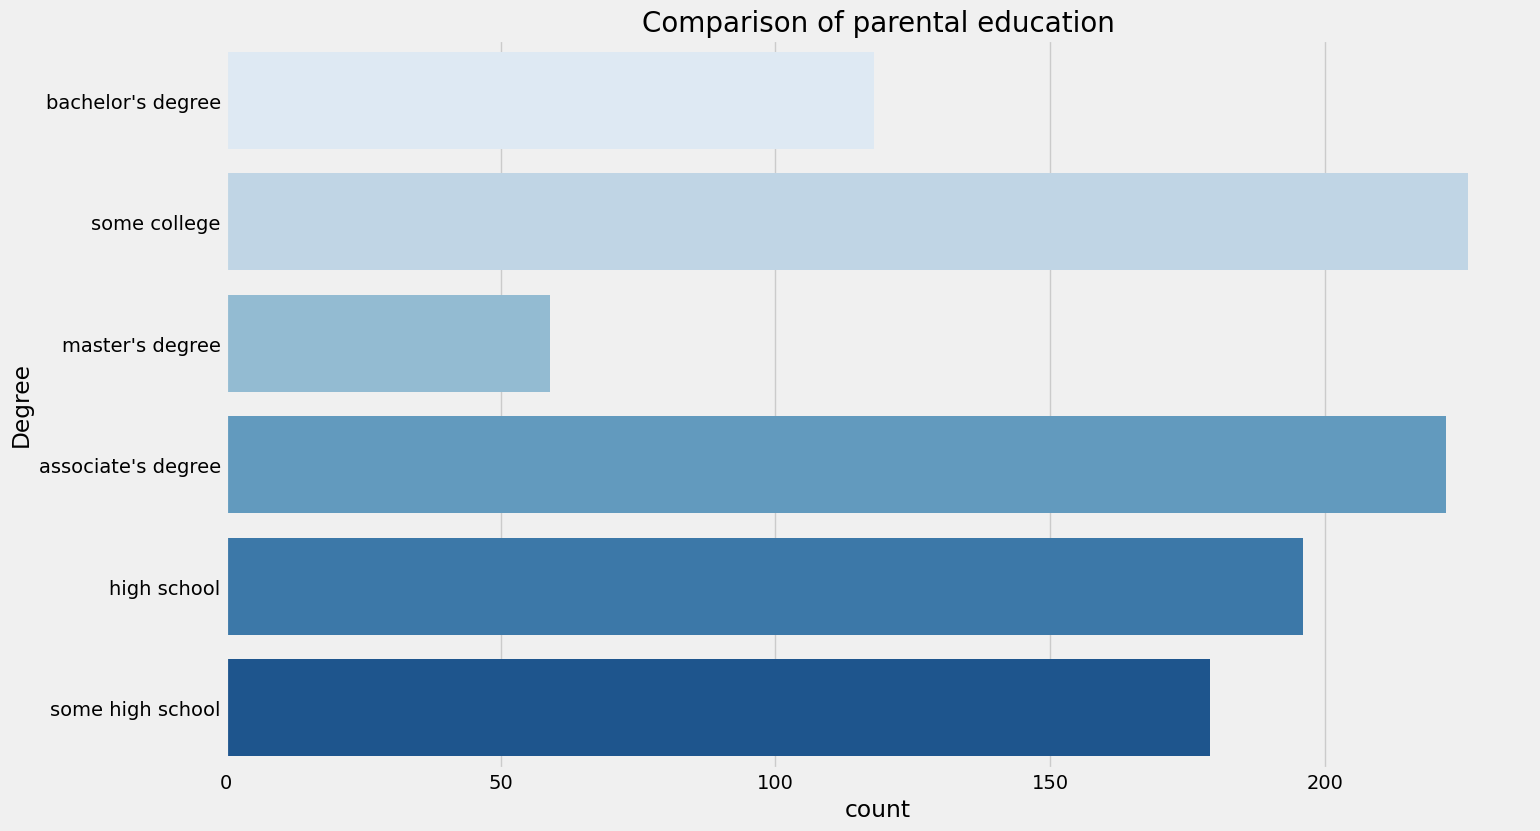

In [32]:
plt.rcParams['figure.figsize'] = (15,9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title("Comparison of parental education", fontweight = 30, fontsize = 20)
plt.xlabel('count')
plt.ylabel('Degree')
plt.show()

##### Insights 
- Largest number of parents are from some college

#### Bivariate Analysis (Is parental education has any impact on student's performance ?)

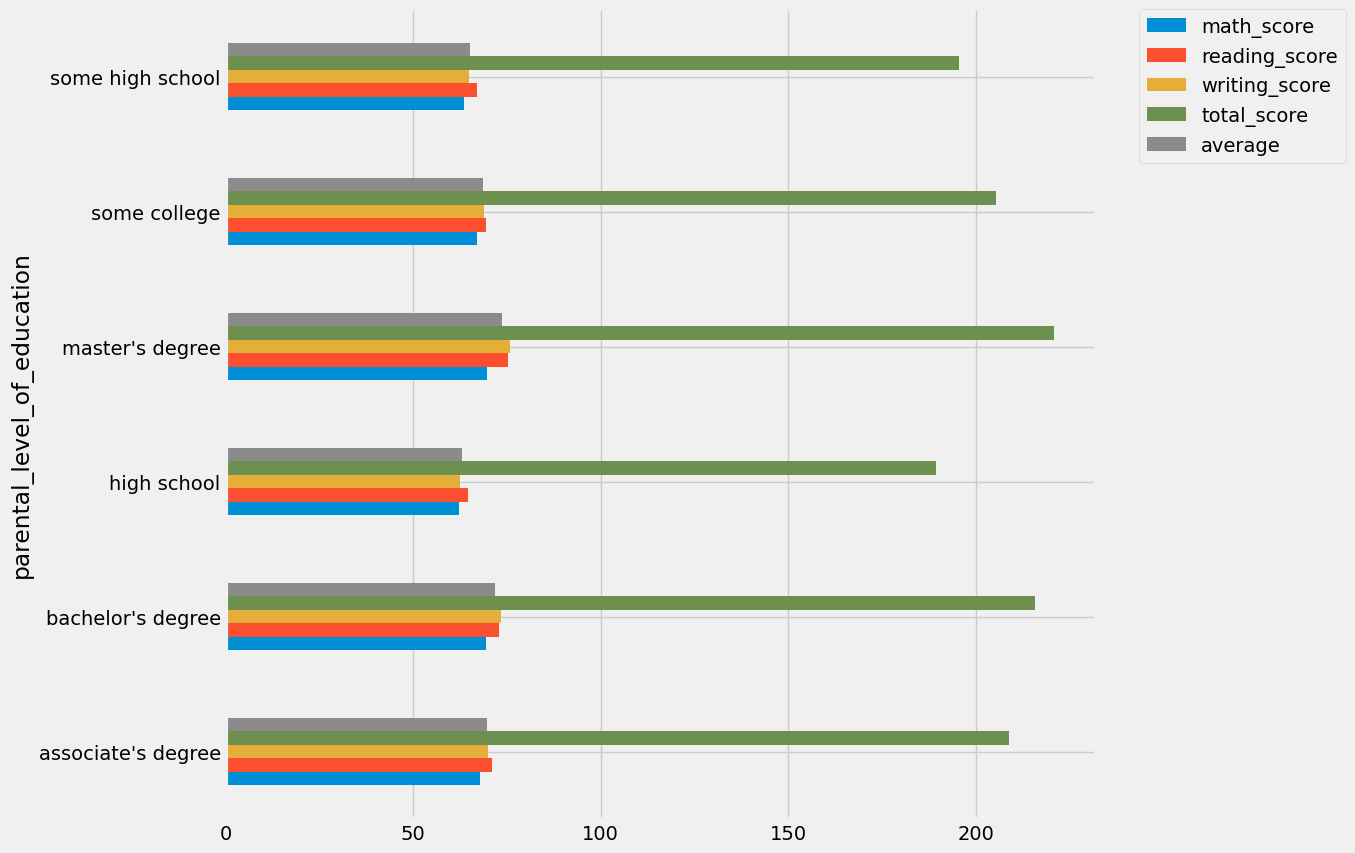

In [33]:
numeric_cols = df.select_dtypes(include = 'number')
df.groupby('parental_level_of_education')[numeric_cols.columns].mean().plot(kind = 'barh', figsize = (10,10))
plt.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0.)
plt.show()

##### Insights
- The score of student whose parents possess master and bachelor level education are higher than others

#### 4.4 Lunch Column
- Which type of lunch is most common among students ?
- What is the effect of lunch type on test results ?

#### Univariate Analysis (Which type of lunch is most common among students ?)

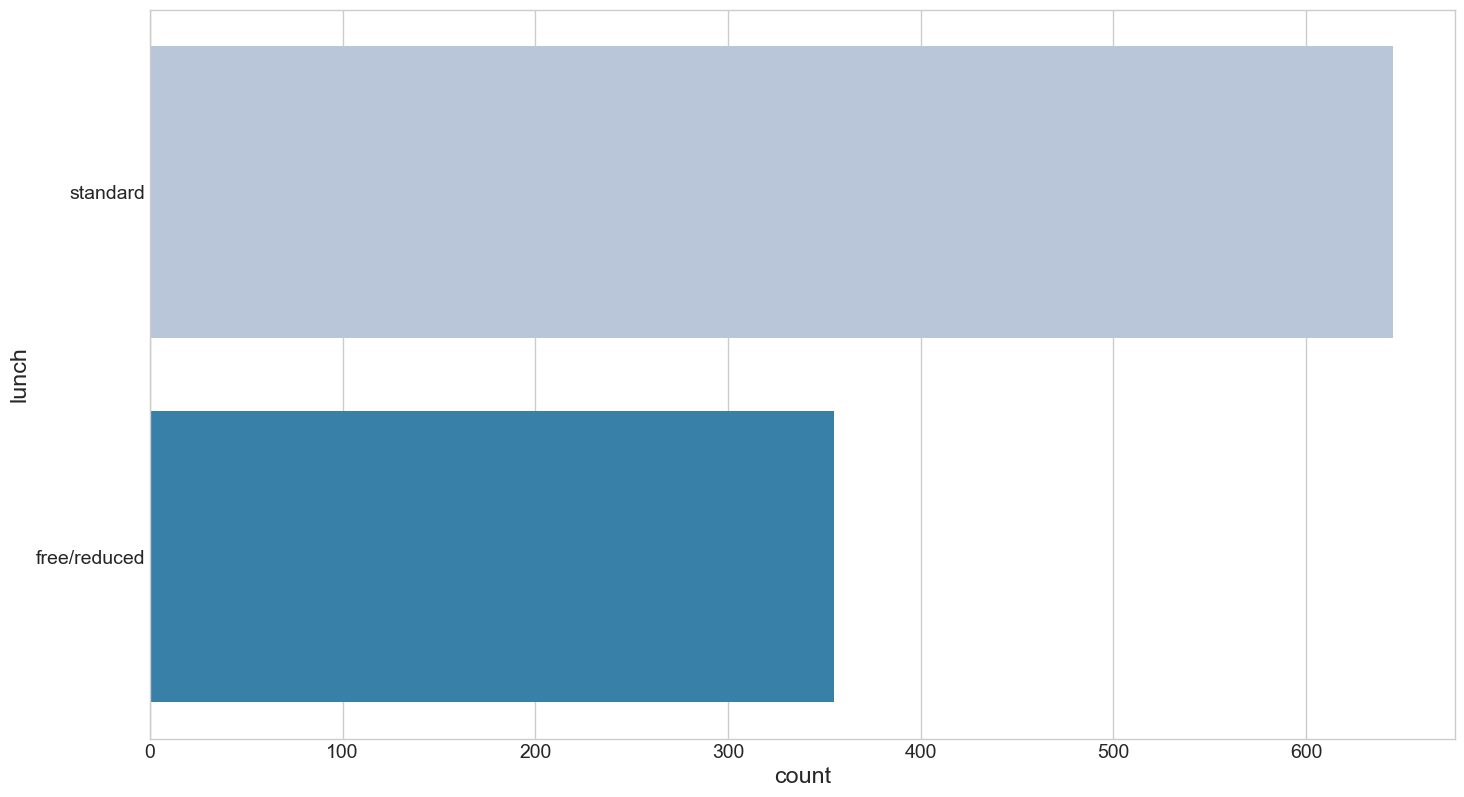

In [34]:
plt.rcParams['figure.figsize'] = (15,9)
plt.style.use('seaborn-v0_8-whitegrid')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title("")
plt.show()

##### Insights
- Students being served Standard lunch was more than free lunch

#### Bivariate Analysis (Is lunch type intake has any impact on student's performance ?)

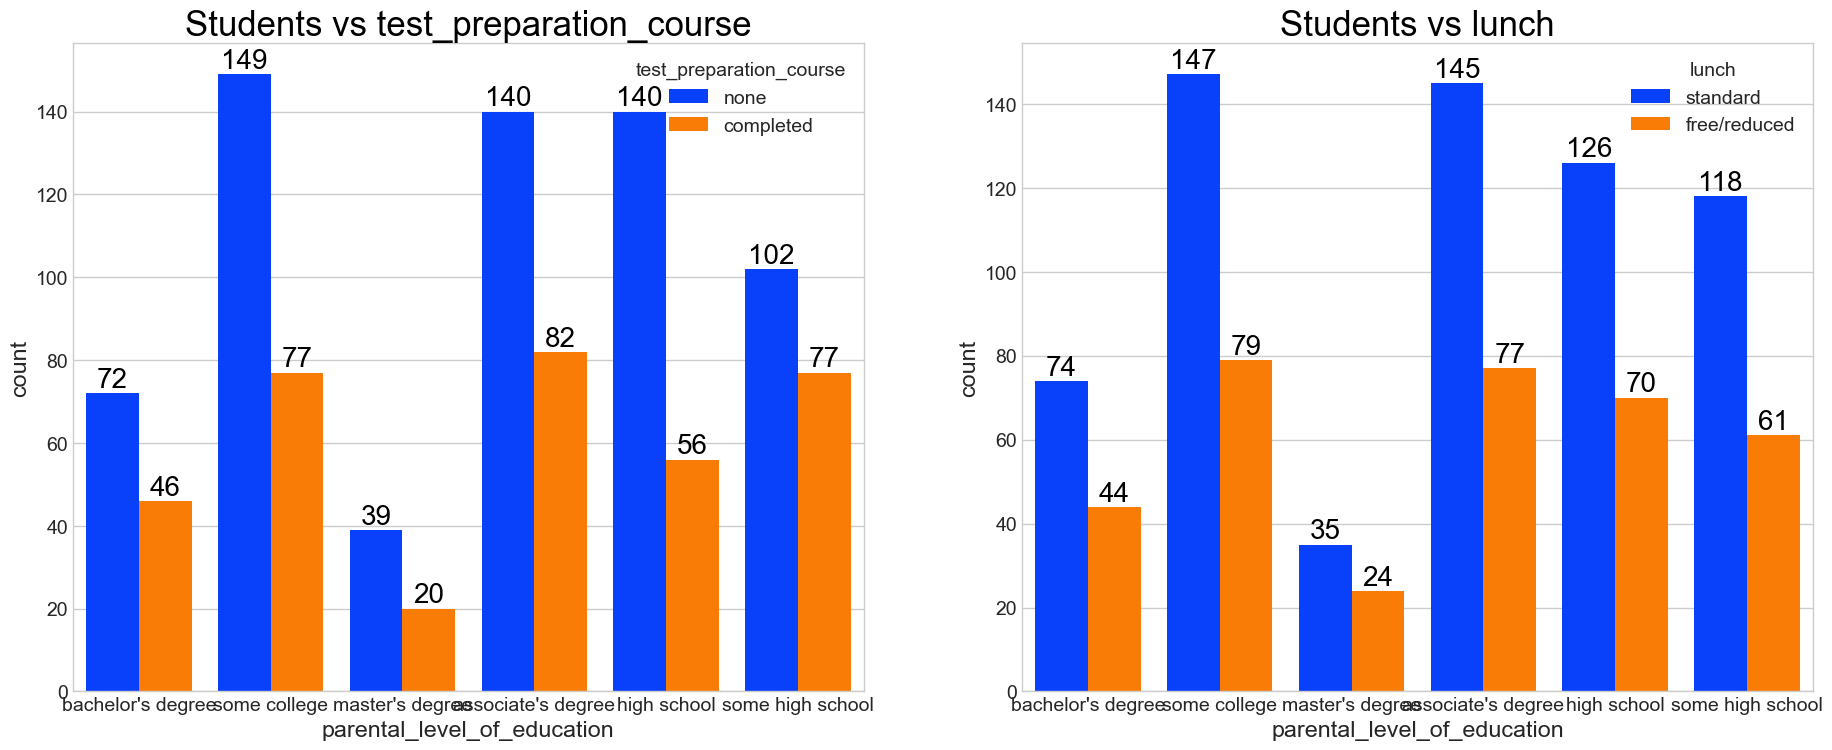

In [35]:
f, ax = plt.subplots(1,2, figsize = (20,8))
sns.countplot(x = df['parental_level_of_education'], data = df, palette = 'bright', hue = 'test_preparation_course', saturation = 0.95, ax = ax[0])
ax[0].set_title("Students vs test_preparation_course", color = 'black', size = 25)
for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 20)

sns.countplot(x = df['parental_level_of_education'], data = df, palette = 'bright', hue = 'lunch', saturation = 0.95, ax = ax[1])
ax[1].set_title("Students vs lunch", color = 'black', size = 25)
for container in ax[1].containers:
    ax[1].bar_label(container, color = 'black', size = 20)
plt.show()

##### Insights
- Students who get standard lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 Test Preparation Course Column

- Which type of lunch is most common among students ?
- Is test preparation course has any impact on student's performance ?

#### Bivariate Analysis (is test preparation course has any impact on student's performance ?)

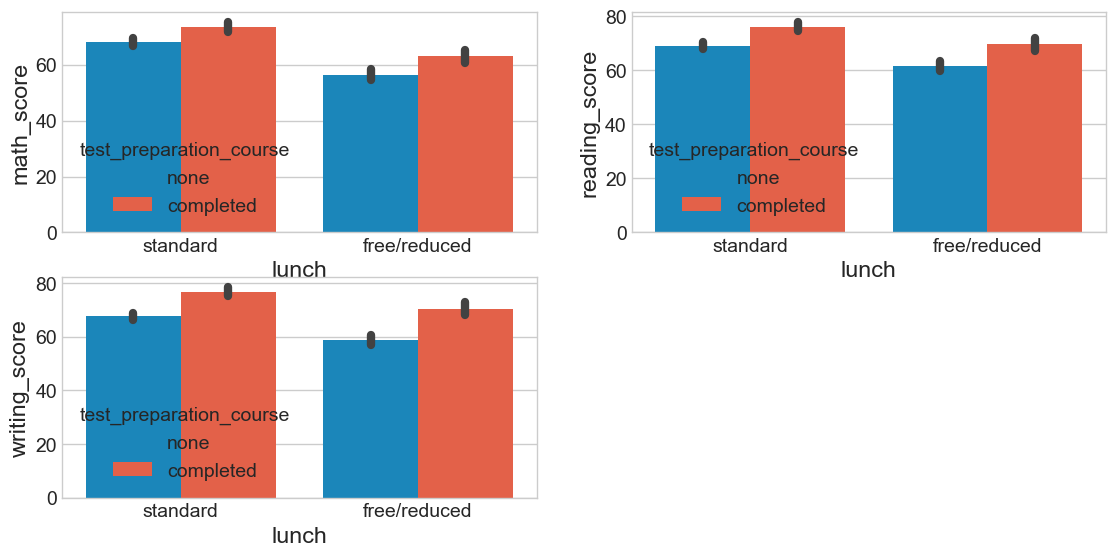

In [36]:
plt.figure(figsize = (12, 6))
plt.subplot(2,2,1)
sns.barplot(x = df['lunch'], y = df['math_score'], hue = df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot(x = df['lunch'], y = df['reading_score'], hue = df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot(x = df['lunch'], y = df['writing_score'], hue = df['test_preparation_course'])
plt.show()

##### Insights
- Students who have completed the test preparation course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 Checking Outliers

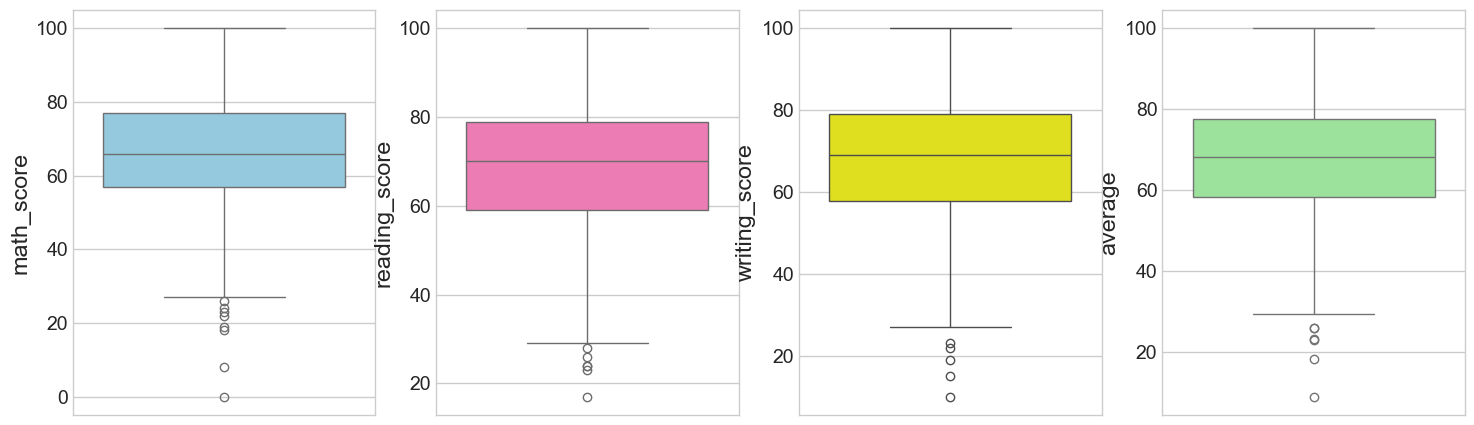

In [37]:
plt.subplots(1, 4, figsize = (16,5))
plt.subplot(1,4,1)
sns.boxplot(df['math_score'], color = 'skyblue')
plt.subplot(1,4,2)
sns.boxplot(df['reading_score'], color = 'hotpink')
plt.subplot(1,4,3)
sns.boxplot(df['writing_score'], color = 'yellow')
plt.subplot(1,4,4)
sns.boxplot(df['average'], color = 'lightgreen')
plt.show()

#### 4.4.7 Multivariate Analysis using Pairplot

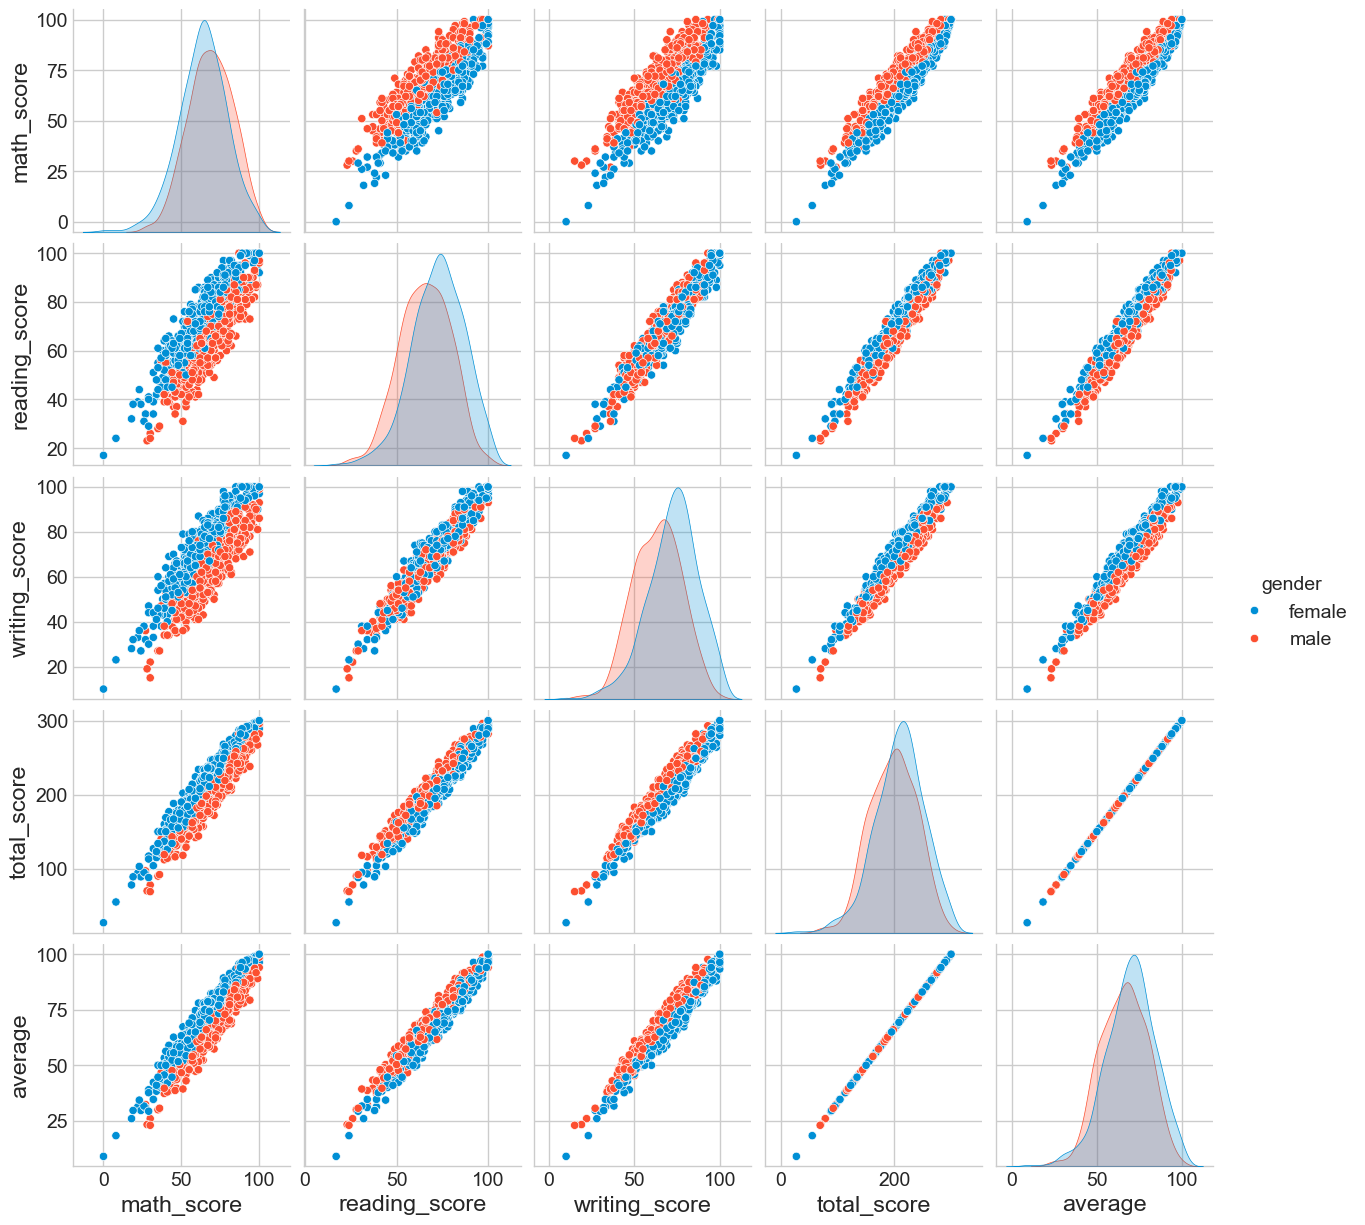

In [38]:
sns.pairplot(df, hue = 'gender')
plt.show()

##### Insights
- From the above plot it is clear that all the scores increase linea

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.